In [12]:
import pandas as pd

df = pd.read_excel("data.xlsx")
df.head(16)

,Sample,Description,C 1s,O 1s,P 2p,Zr 3d,Si 2p,WCA mean,WCA SD
0,S1,bare ZrNT,60.4081,29.282800,NaN,10.30910,NaN,7.00,0.0000
1,S2,ZrNT Soak in OA,38.6840,54.601000,NaN,0.00000,NaN,144.00,1.4500
2,S3,ZrNT Soak in ODPA,56.7127,30.655400,0.999210,11.63260,NaN,153.40,4.7200
3,S4,ZrNT Soak in OA:ODPA (1:1) mix,60.4081,29.282800,0.000000,10.30910,NaN,136.00,2.3400
4,S5,ZrNT OA soak → ODPA stamp,43.7313,36.963200,0.869207,11.67000,0.086976,153.41,5.8000
5,S6,ZrNT OA soak → DI rinse → ODPA stamp,48.9518,33.527900,0.919508,9.69565,2.125450,138.75,5.7000
6,S7,ZrNT ODPA soak → OA stamp,60.0977,24.792200,2.300850,7.95559,NaN,108.33,4.5000
7,S8,ZrNT ODPA soak → DI rinse → OA stamp,61.6824,24.306400,2.398430,7.35598,NaN,122.25,3.4000
8,S9,ZrNT OA:ODPA mix soak → OA stamp,69.2261,23.569800,0.000000,4.43515,0.000000,139.75,1.2000
9,S10,ZrNT OA:ODPA mix soak → DI rinse → OA stamp,46.2152,24.263600,1.133360,8.31607,11.394900,134.25,9.6000


In [16]:
df.shape
df.columns
df.dtypes

Sample          object
Description     object
C 1s           float64
O 1s           float64
P 2p           float64
Zr 3d          float64
Si 2p          float64
WCA mean       float64
WCA SD         float64
Molecule        object
Method          object
Surface         object
dtype: object

In [17]:
df.columns = df.columns.str.strip()
df.columns

Index(['Sample', 'Description', 'C 1s', 'O 1s', 'P 2p', 'Zr 3d', 'Si 2p',
       'WCA mean', 'WCA SD', 'Molecule', 'Method', 'Surface'],
      dtype='object')

In [18]:
cols = ["C 1s", "O 1s", "P 2p", "Zr 3d", "Si 2p", "WCA mean", "WCA SD"]

for col in cols:
    df[col] = df[col].astype(str).str.replace(",", ".")
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [19]:
df.dtypes

Sample          object
Description     object
C 1s           float64
O 1s           float64
P 2p           float64
Zr 3d          float64
Si 2p          float64
WCA mean       float64
WCA SD         float64
Molecule        object
Method          object
Surface         object
dtype: object

In [20]:
df = df.dropna(subset=["WCA mean"])

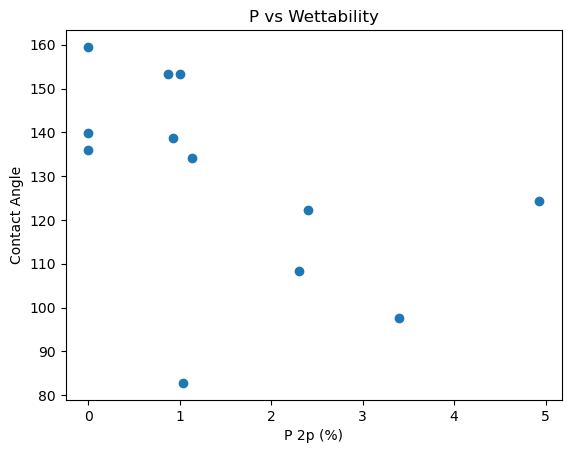

In [21]:
import matplotlib.pyplot as plt

plt.scatter(df["P 2p"], df["WCA mean"])
plt.xlabel("P 2p (%)")
plt.ylabel("Contact Angle")
plt.title("P vs Wettability")

plt.show()

In [29]:
def extract_surface(desc):
    desc = str(desc).lower()
    if "zrnt" in desc:
        return "ZrNT"
    elif "zrco" in desc:
        return "ZrCO"
    else:
        return "Unknown"


def extract_soak(desc):
    desc = str(desc).lower()
    
    if "soak in oa:odpa" in desc or "mix soak" in desc:
        return "Mix"
    elif "soak in oa" in desc or "oa soak" in desc:
        return "OA"
    elif "soak in odpa" in desc or "odpa soak" in desc:
        return "ODPA"
    else:
        return "None"


def extract_rinse(desc):
    return "rinse" in str(desc).lower()


def extract_stamp(desc):
    desc = str(desc).lower()
    
    if "odpa stamp" in desc:
        return "ODPA"
    elif "oa stamp" in desc:
        return "OA"
    else:
        return "None"

In [30]:
df["Surface"] = df["Description"].apply(extract_surface)
df["Soak"] = df["Description"].apply(extract_soak)
df["Rinse"] = df["Description"].apply(extract_rinse)
df["Stamp"] = df["Description"].apply(extract_stamp)

In [24]:
def classify_surface(desc):
    desc = str(desc).lower()
    
    if "zrnt" in desc:
        return "ZrNT"
    elif "zrco" in desc:
        return "ZrCO"
    else:
        return "Unknown"

df["Surface"] = df["Description"].apply(classify_surface)

df[["Sample", "Surface"]]

,Sample,Surface
0,S1,ZrNT
1,S2,ZrNT
2,S3,ZrNT
3,S4,ZrNT
4,S5,ZrNT
5,S6,ZrNT
6,S7,ZrNT
7,S8,ZrNT
8,S9,ZrNT
9,S10,ZrNT


In [31]:
df[["Description", "Surface", "Soak", "Rinse", "Stamp"]]

,Description,Surface,Soak,Rinse,Stamp
0,bare ZrNT,ZrNT,None,False,None
1,ZrNT Soak in OA,ZrNT,OA,False,None
2,ZrNT Soak in ODPA,ZrNT,ODPA,False,None
3,ZrNT Soak in OA:ODPA (1:1) mix,ZrNT,Mix,False,None
4,ZrNT OA soak → ODPA stamp,ZrNT,OA,False,ODPA
5,ZrNT OA soak → DI rinse → ODPA stamp,ZrNT,OA,True,ODPA
6,ZrNT ODPA soak → OA stamp,ZrNT,ODPA,False,OA
7,ZrNT ODPA soak → DI rinse → OA stamp,ZrNT,ODPA,True,OA
8,ZrNT OA:ODPA mix soak → OA stamp,ZrNT,Mix,False,OA
9,ZrNT OA:ODPA mix soak → DI rinse → OA stamp,ZrNT,Mix,True,OA


In [32]:
df.groupby("Rinse")["WCA mean"].mean()

Rinse
False    109.4700
True     138.6875
Name: WCA mean, dtype: float64

In [33]:
df.groupby(["Soak", "Stamp"])["WCA mean"].mean()

Soak  Stamp
Mix   None     114.000
      OA       137.000
      ODPA     141.875
None  None      41.000
OA    None     113.400
      ODPA     146.080
ODPA  None     125.550
      OA       115.290
Name: WCA mean, dtype: float64

In [34]:
df.groupby("Rinse")["WCA mean"].mean()

Rinse
False    109.4700
True     138.6875
Name: WCA mean, dtype: float64

In [35]:
df.groupby("Stamp")["WCA mean"].mean()

Stamp
None     98.4875
OA      126.1450
ODPA    143.9775
Name: WCA mean, dtype: float64

In [36]:
df.groupby(["Soak", "Stamp"])["WCA mean"].mean()

Soak  Stamp
Mix   None     114.000
      OA       137.000
      ODPA     141.875
None  None      41.000
OA    None     113.400
      ODPA     146.080
ODPA  None     125.550
      OA       115.290
Name: WCA mean, dtype: float64

In [37]:
df.groupby(["Surface", "Stamp"])["WCA mean"].mean()

Surface  Stamp
ZrCO     None      86.8750
ZrNT     None     110.1000
         OA       126.1450
         ODPA     143.9775
Name: WCA mean, dtype: float64

In [38]:
df.sort_values("WCA mean", ascending=False)[
    ["Sample", "Description", "WCA mean"]
]

,Sample,Description,WCA mean
11,S12,ZrNT OA:ODPA mix soak → DI rinse → ODPA stamp,159.50
4,S5,ZrNT OA soak → ODPA stamp,153.41
2,S3,ZrNT Soak in ODPA,153.40
1,S2,ZrNT Soak in OA,144.00
8,S9,ZrNT OA:ODPA mix soak → OA stamp,139.75
5,S6,ZrNT OA soak → DI rinse → ODPA stamp,138.75
3,S4,ZrNT Soak in OA:ODPA (1:1) mix,136.00
9,S10,ZrNT OA:ODPA mix soak → DI rinse → OA stamp,134.25
10,S11,ZrNT OA:ODPA mix soak → ODPA stamp,124.25
7,S8,ZrNT ODPA soak → DI rinse → OA stamp,122.25


## Discussion

The wettability of zirconia surfaces is strongly influenced by the interplay between chemical functionalization, processing sequence, and substrate morphology.

Among all investigated samples, the highest contact angle (~159°) was observed for ZrNT samples treated with a mixed OA/ODPA soak followed by rinsing and final ODPA stamping. This suggests that combining initial surface coverage (via mixed soak) with a final strongly binding molecule (ODPA) leads to a highly ordered and stable self-assembled monolayer (SAM).

A key observation is that the **final functionalization step dominates surface behavior**. Samples terminated with ODPA consistently exhibited higher contact angles compared to those terminated with OA. This can be attributed to the strong phosphonic acid binding of ODPA to zirconia (P–O–Zr), resulting in more stable and densely packed SAMs.

In contrast, applying OA as the final step led to reduced hydrophobicity, likely due to weaker surface interactions and disruption of previously formed ODPA layers.

The role of rinsing was found to be nuanced. While in some cases it improved ordering by removing loosely adsorbed molecules, in others it reduced surface coverage and slightly decreased wettability.

Additionally, substrate morphology plays a crucial role. Nanostructured ZrNT surfaces exhibited significantly higher contact angles than compact ZrCO, likely due to increased surface roughness and air trapping effects (Cassie–Baxter regime).

Overall, the results demonstrate that optimal wettability is achieved through a combination of:
- appropriate molecular selection (ODPA),
- controlled processing sequence,
- and nanostructured surface morphology.

## Machine Learning Model
We build a model to predict contact angle (WCA) based on surface chemistry and processing parameters.

In [39]:
from sklearn.model_selection import train_test_split

features = ["C 1s", "O 1s", "P 2p", "Zr 3d", "Rinse", "Soak", "Stamp", "Surface"]

df_ml = pd.get_dummies(df[features], drop_first=True)

X = df_ml
y = df["WCA mean"]

In [61]:
df["Surface"] = df["Description"].apply(extract_surface)
df["Soak"] = df["Description"].apply(extract_soak)
df["Rinse"] = df["Description"].apply(extract_rinse)
df["Stamp"] = df["Description"].apply(extract_stamp)

In [62]:
df[["Description", "Soak", "Stamp"]]

,Description,Soak,Stamp
0,bare ZrNT,None,None
1,ZrNT Soak in OA,OA,None
2,ZrNT Soak in ODPA,ODPA,None
3,ZrNT Soak in OA:ODPA (1:1) mix,Mix,None
4,ZrNT OA soak → ODPA stamp,OA,ODPA
5,ZrNT OA soak → DI rinse → ODPA stamp,OA,ODPA
6,ZrNT ODPA soak → OA stamp,ODPA,OA
7,ZrNT ODPA soak → DI rinse → OA stamp,ODPA,OA
8,ZrNT OA:ODPA mix soak → OA stamp,Mix,OA
9,ZrNT OA:ODPA mix soak → DI rinse → OA stamp,Mix,OA


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [41]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: -0.11132808722854315
MAE: 36.22249999999999


In [43]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

P 2p            0.378575
Surface_ZrNT    0.354823
Zr 3d           0.120405
C 1s            0.056364
O 1s            0.031483
Soak_None       0.020726
Stamp_OA        0.016667
Soak_ODPA       0.007750
Soak_OA         0.005988
Stamp_ODPA      0.005815
Rinse           0.001405
dtype: float64

In [74]:
def extract_surface(desc):
    desc = str(desc).lower()
    if "zrnt" in desc:
        return "ZrNT"
    elif "zrco" in desc:
        return "ZrCO"
    else:
        return "Unknown"


def extract_soak(desc):
    desc = str(desc).lower()
    
    if "oa:odpa" in desc or "mix soak" in desc:
        return "Mix"
    elif "soak in oa" in desc or "oa soak" in desc:
        return "OA"
    elif "soak in odpa" in desc or "odpa soak" in desc:
        return "ODPA"
    else:
        return "None"


def extract_rinse(desc):
    return "rinse" in str(desc).lower()


def extract_stamp(desc):
    desc = str(desc).lower()
    
    if "odpa stamp" in desc:
        return "ODPA"
    elif "oa stamp" in desc:
        return "OA"
    else:
        return "None"

In [75]:
df["Surface"] = df["Description"].apply(extract_surface)
df["Soak"] = df["Description"].apply(extract_soak)
df["Rinse"] = df["Description"].apply(extract_rinse)
df["Stamp"] = df["Description"].apply(extract_stamp)

In [76]:
df[["Description", "Soak", "Stamp"]]

,Description,Soak,Stamp
0,bare ZrNT,None,None
1,ZrNT Soak in OA,OA,None
2,ZrNT Soak in ODPA,ODPA,None
3,ZrNT Soak in OA:ODPA (1:1) mix,Mix,None
4,ZrNT OA soak → ODPA stamp,OA,ODPA
5,ZrNT OA soak → DI rinse → ODPA stamp,OA,ODPA
6,ZrNT ODPA soak → OA stamp,ODPA,OA
7,ZrNT ODPA soak → DI rinse → OA stamp,ODPA,OA
8,ZrNT OA:ODPA mix soak → OA stamp,Mix,OA
9,ZrNT OA:ODPA mix soak → DI rinse → OA stamp,Mix,OA


## Data Expansion (Handling Experimental Variability)

To better capture experimental variability, the dataset is expanded using the reported standard deviation (WCA SD). This simulates multiple measurements per sample and improves model robustness.

In [81]:
import numpy as np

expanded_data = []

for _, row in df.iterrows():
    mean = row["WCA mean"]
    std = row["WCA SD"]
    
    if not np.isnan(std):
        samples = np.random.normal(mean, std, 5)
        
        for s in samples:
            new_row = row.copy()
            new_row["WCA mean"] = s
            expanded_data.append(new_row)

df_expanded = pd.DataFrame(expanded_data)

In [82]:
def process_sequence(row):
    soak = row["Soak"]
    stamp = row["Stamp"]
    rinse = row["Rinse"]
    
    seq = soak
    
    if rinse:
        seq += "_rinse"
    
    if stamp != "None":
        seq += "_to_" + stamp
    
    return seq

df_expanded["Process"] = df_expanded.apply(process_sequence, axis=1)

In [79]:
def process_sequence(row):
    soak = row["Soak"]
    stamp = row["Stamp"]
    rinse = row["Rinse"]
    
    seq = soak
    
    if rinse:
        seq += "_rinse"
    
    if stamp != "None":
        seq += "_to_" + stamp
    
    return seq

df_expanded["Process"] = df_expanded.apply(process_sequence, axis=1)

In [85]:
df_expanded[["Description", "Soak", "Stamp", "Process"]].head(10)

,Description,Soak,Stamp,Process
0,bare ZrNT,None,None,None
0,bare ZrNT,None,None,None
0,bare ZrNT,None,None,None
0,bare ZrNT,None,None,None
0,bare ZrNT,None,None,None
1,ZrNT Soak in OA,OA,None,OA
1,ZrNT Soak in OA,OA,None,OA
1,ZrNT Soak in OA,OA,None,OA
1,ZrNT Soak in OA,OA,None,OA
1,ZrNT Soak in OA,OA,None,OA


In [87]:
X = pd.get_dummies(df_expanded[features], drop_first=True)
y = df_expanded["WCA mean"]

## Machine Learning Model (Expanded Dataset)

In [90]:
features = ["C 1s", "O 1s", "P 2p", "Zr 3d", "Surface", "Process"]

X = pd.get_dummies(df_expanded[features], drop_first=True)
y = df_expanded["WCA mean"]

In [91]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [92]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [93]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: 0.9792608595525191
MAE: 5.28471837710341


In [94]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

Process_None                 0.468761
Surface_ZrNT                 0.286219
P 2p                         0.125439
Zr 3d                        0.057164
C 1s                         0.030009
O 1s                         0.025043
Process_ODPA_to_OA           0.004517
Process_Mix_rinse_to_OA      0.001199
Process_OA                   0.000859
Process_ODPA                 0.000461
Process_Mix_rinse_to_ODPA    0.000165
Process_Mix_to_ODPA          0.000062
Process_ODPA_rinse_to_OA     0.000035
Process_OA_to_ODPA           0.000028
Process_OA_rinse_to_ODPA     0.000028
Process_Mix_to_OA            0.000011
dtype: float64

In [95]:
importance.sort_values(ascending=False)

Process_None                 0.468761
Surface_ZrNT                 0.286219
P 2p                         0.125439
Zr 3d                        0.057164
C 1s                         0.030009
O 1s                         0.025043
Process_ODPA_to_OA           0.004517
Process_Mix_rinse_to_OA      0.001199
Process_OA                   0.000859
Process_ODPA                 0.000461
Process_Mix_rinse_to_ODPA    0.000165
Process_Mix_to_ODPA          0.000062
Process_ODPA_rinse_to_OA     0.000035
Process_OA_to_ODPA           0.000028
Process_OA_rinse_to_ODPA     0.000028
Process_Mix_to_OA            0.000011
dtype: float64

In [96]:
df_ml2 = df_expanded[df_expanded["Process"] != "None"]

In [97]:
features = ["C 1s", "O 1s", "P 2p", "Zr 3d", "Surface", "Process"]

X = pd.get_dummies(df_ml2[features], drop_first=True)
y = df_ml2["WCA mean"]

In [98]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

R2: 0.9571336705708764
MAE: 2.9440424635079645


Surface_ZrNT                 0.536848
P 2p                         0.344800
Zr 3d                        0.072747
Process_ODPA_to_OA           0.013767
O 1s                         0.013237
C 1s                         0.010039
Process_OA                   0.003821
Process_Mix_rinse_to_OA      0.002202
Process_ODPA                 0.001057
Process_OA_to_ODPA           0.000463
Process_ODPA_rinse_to_OA     0.000411
Process_Mix_to_ODPA          0.000298
Process_OA_rinse_to_ODPA     0.000122
Process_Mix_to_OA            0.000096
Process_Mix_rinse_to_ODPA    0.000092
dtype: float64